Import libraries

In [ ]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import numpy as np 
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F

import os
os.makedirs("data/", exist_ok=True)

Define constants

In [ ]:
NUM_CLIENTS = 4 # Number of clients 
BATCH_SIZE = 128 # Batch size for each client 
DATA_NUM = 300 # Number of data points for each client
NOISE_DIM = 2 # Dimension of noise vector for generator 
DATA_DIM = 2 # Dimension of data vector for discriminator 
HIDDEN_DIM = 16 # Dimension of hidden layer for both generator and discriminator
LR = 0.00005 # Learning rate for both generator and discriminator 
CLS_LR = 0.001
C_EPOCHS = 2 # Number of epochs for training
S_EPOCHS = 2
DISC_EPOCHS = 1
N_CLS = 3
P=0.9

Define helper functions

In [3]:
def generate_data(mean, var, num_samples): # Generate data from a Gaussian distribution with given mean and variance 
    return np.random.normal(mean, var, (num_samples, DATA_DIM))

def plot_data(data, labels=None, title=None, show=True): # Plot data as scatter plot with optional labels and title 
    # plt.figure() 
    if labels is None: 
        plt.scatter(data[:,0], data[:,1], edgecolor='black') 
    else: 
        c_dict = {0:'r', 1:'lime', 2:'b'}
        plt.scatter(data[:,0], data[:,1], c = [c_dict[l] for l in labels]) 
    if title is not None: 
        plt.title(title)
    if show:
        plt.show()

def plot_loss(losses, title=None): # Plot losses as line plot with optional title 
    plt.figure() 
    plt.plot(losses) 
    if title is not None: 
        plt.title(title) 
    plt.show()
    
def _fix_seed(seed: int):
    """Fix the seed of the experiment and runs

    Args:
        seed (int): Random seed
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

Define generator and discriminator models

In [ ]:
class Generator(nn.Module): # A simple feedforward network that takes noise vector as input and outputs data vector 
    def __init__(self): 
        super(Generator, self).__init__() 
        self.fc1 = nn.Linear(NOISE_DIM, 128) 
        self.fc2 = nn.Linear(128, 256) 
        self.fc3 = nn.Linear(256, DATA_DIM) 
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = 7*self.tanh(self.fc3(x))
        # x = self.fc3(x)
        return x
    
class Discriminator(nn.Module): # A simple feedforward network that takes data vector as input and outputs probability of being real 
    def __init__(self): 
        super(Discriminator, self).__init__() 
        self.fc1 = nn.Linear(DATA_DIM, 256) 
        self.fc2 = nn.Linear(256, 128) 
        self.fc3 = nn.Linear(128, 1) 
        self.relu = nn.LeakyReLU(0.2) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class cDiscriminator(nn.Module):
    def __init__(self): 
        super(cDiscriminator, self).__init__() 
        self.fc1 = nn.Linear(DATA_DIM, 256) 
        self.fc2 = nn.Linear(256, 128) 
        self.fc3 = nn.Linear(128, 1) 
        self.relu = nn.LeakyReLU(0.2) 
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.sigmoid(self.fc3(x)))
        return x
    
class Classifier(nn.Module):
    def __init__(self): 
        super(Classifier, self).__init__() 
        self.fc1 = nn.Linear(DATA_DIM, 256) 
        self.fc2 = nn.Linear(256, 128) 
        self.fc3 = nn.Linear(128, N_CLS) 
        self.lrelu = nn.LeakyReLU(0.1) 
        # self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.lrelu(self.fc1(x))
        x = self.lrelu(self.fc2(x))
        x = self.fc3(x)
        # x = self.softmax(x)
        return x

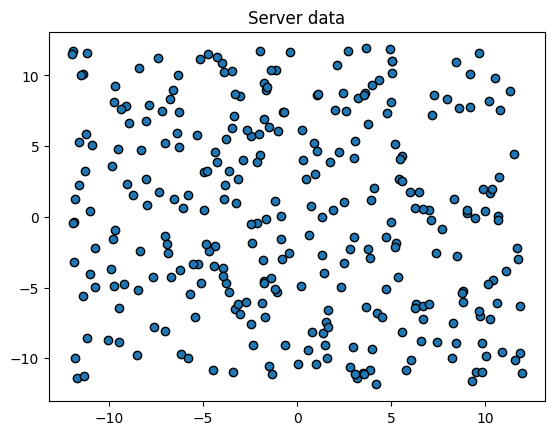

(300, 3)


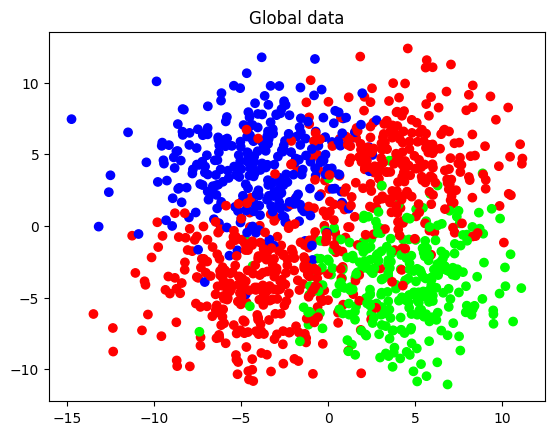

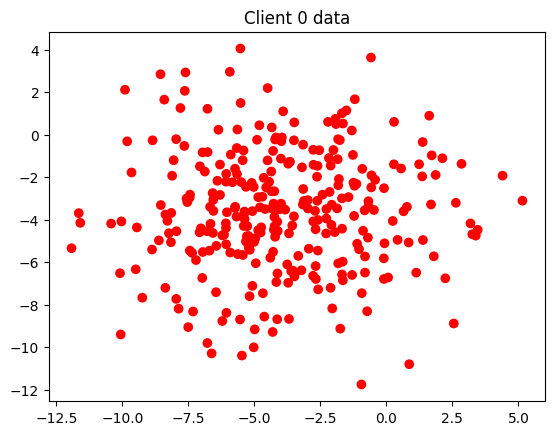

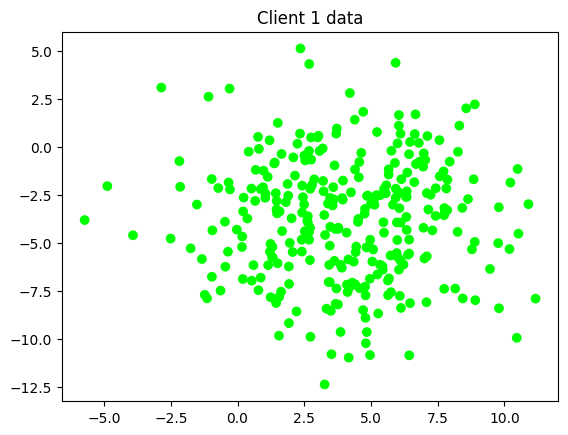

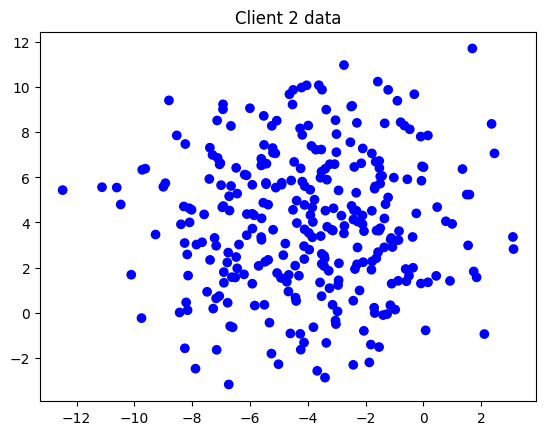

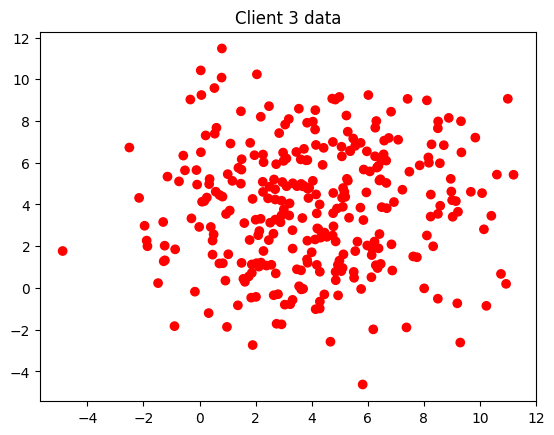

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Use GPU if available

bce_loss = nn.BCELoss()
cls_loss = nn.CrossEntropyLoss()


_fix_seed(123)
server_classifier = Classifier().to(device)
discriminators = [cDiscriminator().to(device) for _ in range(NUM_CLIENTS)]
Classifiers = [Classifier().to(device) for _ in range(NUM_CLIENTS)]

cls_optimizer = optim.Adam(server_classifier.parameters(), lr=CLS_LR)
dis_optimizers = [optim.RMSprop(discriminator.parameters(), lr=LR) for discriminator in discriminators]
cls_optimizers = [optim.Adam(Classifier.parameters(), lr=CLS_LR) for Classifier in Classifiers]


server_data = np.random.uniform(-12, 12, (DATA_NUM, DATA_DIM))
plot_data(server_data, title="Server data") 
global_data = np.array([np.concatenate((generate_data((8 * (i % 2)-4, 8 * (i // 2)-4), 3, DATA_NUM), np.ones((DATA_NUM, 1))*(i%3)), axis=1) for i in range(NUM_CLIENTS)]).reshape(-1,3) # Server data is sampled from all four Gaussians
np.random.shuffle(global_data)
client_data = [np.concatenate((generate_data((8 * (i % 2)-4, 8 * (i // 2) -4), 3, DATA_NUM), np.ones((DATA_NUM, 1))*(i%3)), axis=1) for i in range(NUM_CLIENTS)] # Client data is sampled from one of the four Gaussians
print(client_data[0].shape)

plot_data(global_data, title="Global data", labels = global_data[:,2]) 
for i in range(NUM_CLIENTS): 
    plot_data(client_data[i], title=f"Client {i} data", labels = client_data[i][:,2])

server_dl = torch.utils.data.DataLoader(torch.from_numpy(server_data).float(), batch_size=BATCH_SIZE, shuffle=True) # Server data loader
clients_dls = [torch.utils.data.DataLoader(torch.from_numpy(client_data[i]).float(), batch_size=BATCH_SIZE, shuffle=True) for i in range(NUM_CLIENTS)] # Client data loaders

In [6]:
def c_disc_train(discriminator, optimizer_d, dl, epochs, device):
        
    criterion = bce_loss
    dataloader = dl
    for _ in range(epochs):
        total_dloss = 0
        for data in dataloader:
            data, _ = data[:, :-1], data[:, -1].long()
            del _
            real_data = data.to(device)
            fake_data = server_dl.dataset[torch.randint(0, len(server_dl.dataset), (data.size(0),))] # 서버 데이터셋에서 랜덤하게 데이터 추출
            fake_data = fake_data.to(device)
               
            optimizer_d.zero_grad() 
            real_output = discriminator(real_data)
            fake_output = discriminator(fake_data.detach()) 
            loss_d_real = criterion(real_output.squeeze(), torch.full((data.size(0),), 1).float().to(device))
            loss_d_fake = criterion(fake_output.squeeze(), torch.full((data.size(0),), 0).float().to(device))
            
            # loss_d = loss_d_real + loss_d_fake + gradient_penalty
            loss_d = loss_d_real + loss_d_fake
            loss_d.backward() 
            optimizer_d.step()
            total_dloss += loss_d.item()
        total_dloss /= len(dataloader)

    return discriminator, total_dloss 

def train_cls(classifier, optimizer, dl, epochs, device):
    criterion = cls_loss
    dataloader = dl
    for _ in range(epochs):
        total_loss = 0
        for i, data in enumerate(dataloader):
            data, label = data[:, :-1], data[:, -1].long()
            optimizer.zero_grad()
            output = classifier(data.to(device))
            loss = criterion(output, label.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        total_loss /= len(dataloader)
    return classifier, total_loss



for t in range(DISC_EPOCHS):
    dloss_c_tot = 0
    for i in range(NUM_CLIENTS): 
        discriminators[i], dloss_c = c_disc_train(discriminators[i], dis_optimizers[i], clients_dls[i], 1, device)
    dloss_c_tot += dloss_c
    print(f"Client D loss: {dloss_c_tot:.4f}")

Client D loss: 1.3588


(500, 500)
(500, 500)
(500, 500)
(500, 500)


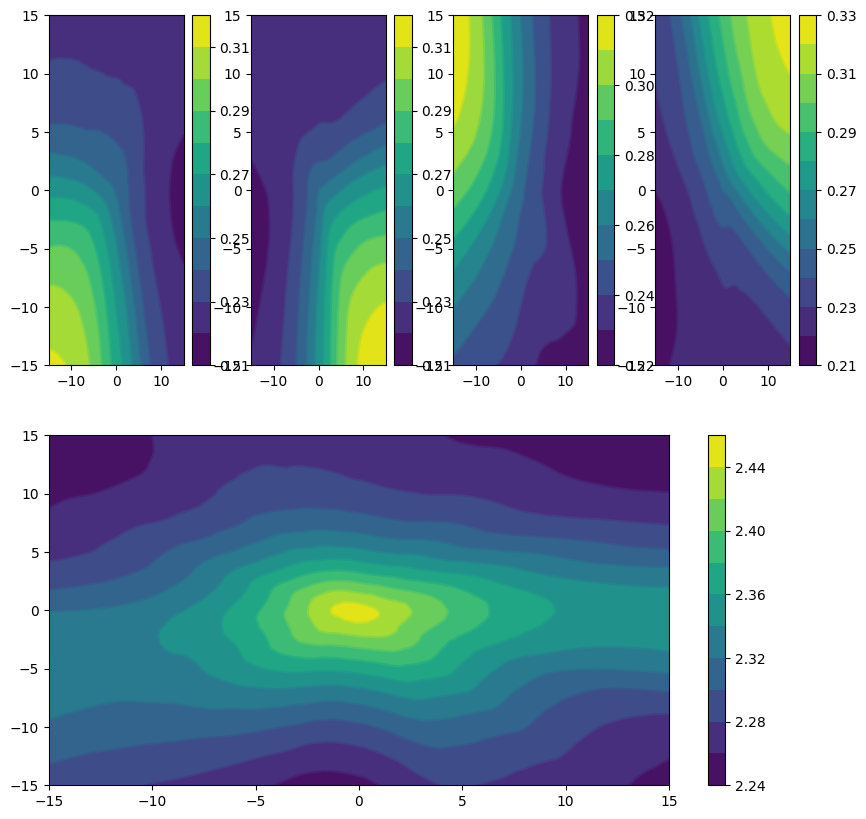

Client C loss: 0.4874
Client C loss: 0.0409
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])


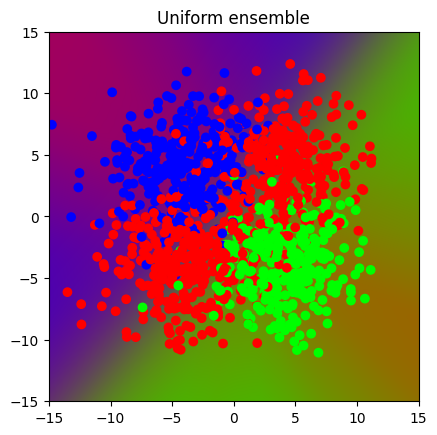

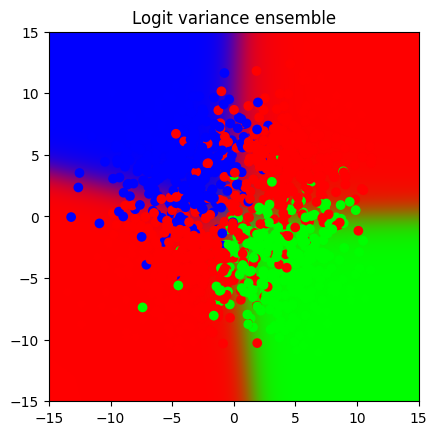

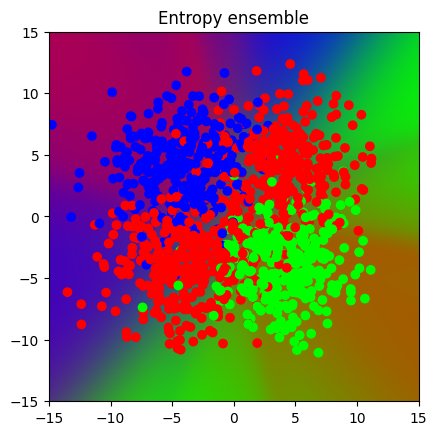

torch.Size([4, 250000, 3])


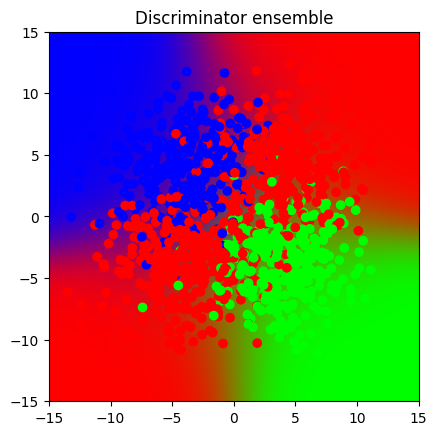

torch.Size([4, 250000, 3])


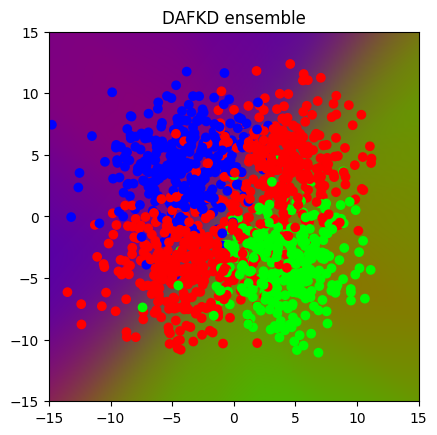

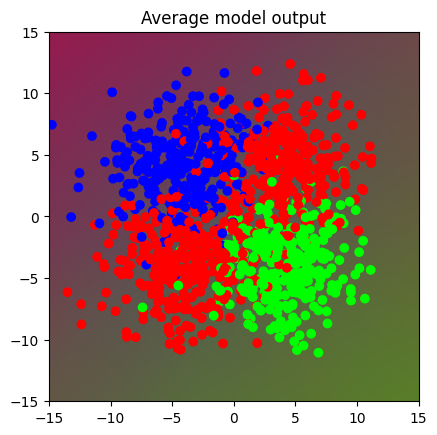

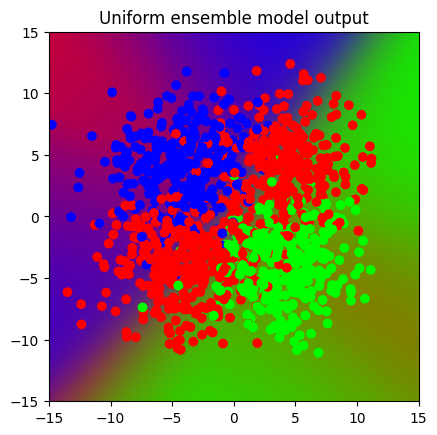

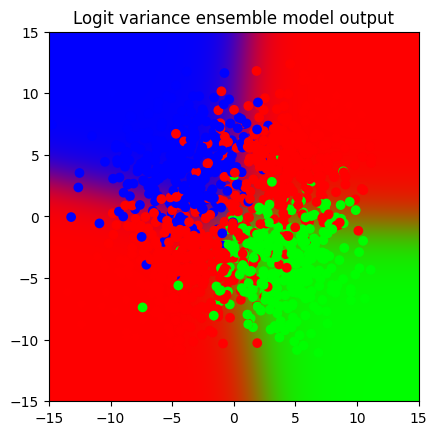

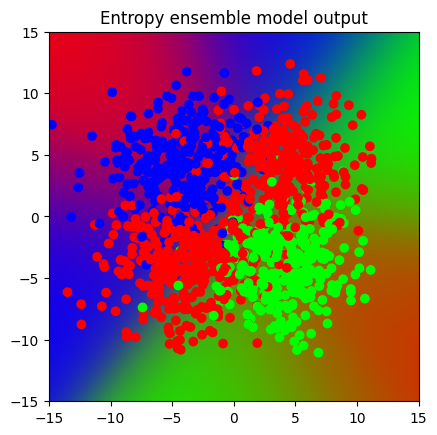

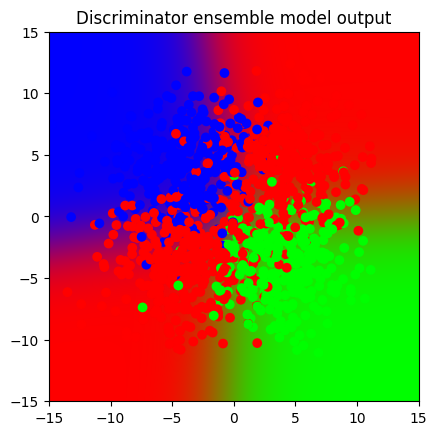

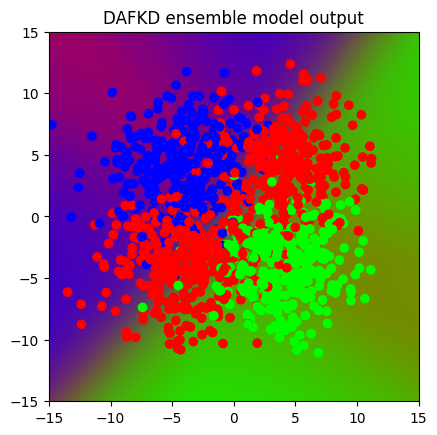

In [7]:
ngridx = 500
ngridy = 500
xmin, xmax = -15, 15
ymin, ymax = -15, 15
xi = np.linspace(xmin, xmax, ngridx)
yi = np.linspace(ymin, ymax, ngridy)

def plot_contour(discriminators, title=None): # Plot discriminator's output as contour plot with optional title
    plt.figure(figsize=(10, 10))
    zs = []
    for i in range(NUM_CLIENTS):
        xx, yy = np.meshgrid(xi, yi)
        x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
        x = torch.from_numpy(x).float().to(device)
        z = discriminators[i](x).detach().cpu().numpy()
        z = z.reshape((ngridy, ngridx))
        # plt.contour(xi, yi, z, levels=10)
        zs.append(z)
        print(z.shape)
    zsum = np.sum(zs, axis=0)
    for i in range(NUM_CLIENTS):
        plt.subplot(2, NUM_CLIENTS, i+1)
        z = zs[i]/zsum
        plt.contour(xi, yi, z, levels=10)
        plt.contourf(xi, yi, z, levels=10)
        plt.colorbar()
    plt.subplot(2, 1, 2)
    plt.contour(xi, yi, zsum, levels=10)
    plt.contourf(xi, yi, zsum, levels=10)
    plt.colorbar()
    plt.show()

plot_contour(discriminators, title="Discriminator output")

def uniform_ensemble(classifiers, data, device):
    for classifier in classifiers:
        classifier.eval()
    data = data.to(device)
    outputs = torch.stack([classifier(data) for classifier in classifiers], dim=0)
    outputs = F.softmax(outputs.mean(dim=0), dim=-1)
    return outputs

def plot_white_box(data=global_data, title=None, show=True, labels=None):
    xx, yy = np.meshgrid(xi, yi)
    z = np.ones((ngridy, ngridx, 3))
    plt.imshow(z, extent=[xmin,xmax , ymin, ymax], origin='lower')
    title = title if title is not None else "White box"
    if labels is not None:
        plot_data(data, title=title, labels = labels, show=show)
    else:
        plot_data(data, title=title, labels = labels, show=show)
    

def plot_unif_ensemble(classifiers, title=None, show = True): # Plot discriminator's output as contour plot with optional title
    # plt.figure(figsize=(10, 10))
    xx, yy = np.meshgrid(xi, yi)
    x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
    x = torch.from_numpy(x).float().to(device)
    z = uniform_ensemble(classifiers, x, device).detach().cpu().numpy()
    print(z.shape)
    z = z.reshape((ngridy, ngridx, N_CLS)) # color
    # plt.contour(xi, yi, z, levels=10)
    plt.imshow(z, extent=[xmin,xmax , ymin, ymax], origin='lower')
    title = title if title is not None else "Ensemble output"
    plot_data(global_data, title=title, labels = global_data[:,2], show=show)
    # plt.colorbar()
    
    # plt.show()

@torch.no_grad()
def disc_ensemble(classifiers, discriminators, data, device):
    for classifier, discriminator in zip(classifiers, discriminators):
        classifier.eval()
        discriminator.eval()
    data = data.to(device)
    outputs = torch.stack([classifier(data) for classifier in classifiers], dim=0)
    print(outputs.shape)
    disc_outputs = torch.stack([discriminator(data) for discriminator in discriminators], dim=0)
    odds = disc_outputs / (1-disc_outputs+1e-12)
    odds_sum = odds.sum(dim=0)
    outputs = outputs * odds / odds_sum
    outputs = F.softmax(outputs.sum(dim=0), dim=-1)
    return outputs

@torch.no_grad()
def dafkd_ensemble(classifiers, discriminators, data, device):
    for classifier, discriminator in zip(classifiers, discriminators):
        classifier.eval()
        discriminator.eval()
    data = data.to(device)
    outputs = torch.stack([classifier(data) for classifier in classifiers], dim=0)
    print(outputs.shape)
    disc_outputs = torch.stack([discriminator(data) for discriminator in discriminators], dim=0)
    odds = F.sigmoid(disc_outputs)
    odds_sum = odds.sum(dim=0)
    outputs = outputs * odds / odds_sum
    outputs = F.softmax(outputs.sum(dim=0), dim=-1)
    return outputs


@torch.no_grad()
def plot_disc_ensemble(classifiers, discriminators, title=None, show=True): # Plot discriminator's output as contour plot with optional title
    # plt.figure(figsize=(10, 10))
    xx, yy = np.meshgrid(xi, yi)
    x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
    x = torch.from_numpy(x).float().to(device)
    z = disc_ensemble(classifiers, discriminators, x, device).detach().cpu().numpy()
    print(z.shape)
    z = z.reshape((ngridy, ngridx, N_CLS)) # color
    # plt.contour(xi, yi, z, levels=10)
    plt.imshow(z, extent=[xmin,xmax , ymin, ymax], origin='lower')
    title = title if title is not None else "Ensemble output"
    plot_data(global_data, title=title, labels = global_data[:,2], show=show)
    # plt.colorbar()
    
    # plt.show(
def plot_ensemble(classifiers, discriminators=None, title=None, show=True, method='unif'):
    xx, yy = np.meshgrid(xi, yi)
    x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
    x = torch.from_numpy(x).float().to(device)
    if method == 'unif':
        z = uniform_ensemble(classifiers, x, device).detach().cpu().numpy()
    elif method == 'disc':
        z = disc_ensemble(classifiers, discriminators, x, device).detach().cpu().numpy()
    elif method == 'logit_var':
        z = logit_var_ensemble(classifiers, x, device).detach().cpu().numpy()
    elif method == 'entropy':
        z = entropy_based_ensemble(classifiers, x, device).detach().cpu().numpy()
    elif method == 'dafkd':
        z = dafkd_ensemble(classifiers, discriminators, x, device).detach().cpu().numpy()
    z = z.reshape((ngridy, ngridx, N_CLS)) # color
    # print(z.max(), z.min())
    # plt.contour(xi, yi, z, levels=10)
    plt.imshow(z, extent=[xmin,xmax , ymin, ymax], origin='lower')
    title = title if title is not None else "Ensemble output"
    plot_data(global_data, title=title, labels = global_data[:,2], show=show)
    
    
    
# classifiers train
for t in range(C_EPOCHS):
    closs_c_tot = 0
    for i in range(NUM_CLIENTS): 
        Classifiers[i], closs_c = train_cls(Classifiers[i], cls_optimizers[i], clients_dls[i], 1, device)
    closs_c_tot += closs_c
    # gloss_c_tot += gloss_c
    print(f"Client C loss: {closs_c_tot:.4f}")

# logit var weighting

def logit_var_ensemble(classifiers, data, device):
    for classifier in classifiers:
        classifier.eval()
    data = data.to(device)
    outputs = torch.stack([classifier(data) for classifier in classifiers], dim=0)
    logit_var = outputs.var(dim=2)
    weight = logit_var / logit_var.sum(dim=0, keepdim=True)
    outputs = outputs * weight.unsqueeze(2)
    outputs = F.softmax(outputs.sum(dim=0), dim=-1)
    return outputs

# entropy based weighting

def entropy_based_ensemble(classifiers, data, device):
    for classifier in classifiers:
        classifier.eval()
    data = data.to(device)
    outputs = torch.stack([classifier(data) for classifier in classifiers], dim=0) # (Client, batch size, N_CLS)
    softmaxs = F.softmax(outputs, dim=2)
    entropy = - (softmaxs * torch.log(softmaxs+1e-12)).sum(dim=2) # (Client, batch size)
    entropy_exp = - torch.exp(entropy)
    weight = entropy_exp / entropy_exp.sum(dim=0, keepdim=True) # (Client, batch size)
    outputs = outputs * weight.unsqueeze(2)
    outputs = F.softmax(outputs.sum(dim=0), dim=-1)
    return outputs

#ensemble train

def ensemble_train(server_classifier, optimizer, classifiers, dl, device, epoch, ens_method ='unif'):
    for classifier in classifiers:
        classifier.eval()
    for _ in range(epoch):
        total_loss = 0
        for data in dl:
            optimizer.zero_grad()
            if ens_method == 'unif':
                ens = uniform_ensemble(classifiers, data, device)
            elif ens_method == 'disc':
                ens = disc_ensemble(classifiers, discriminators, data, device)
            elif ens_method == 'logit_var':
                ens = logit_var_ensemble(classifiers, data, device)
            elif ens_method == 'entropy':
                ens = entropy_based_ensemble(classifiers, data, device)
            elif ens_method == 'dafkd':
                ens = dafkd_ensemble(classifiers, discriminators, data, device)
            output = server_classifier(data.to(device))
            loss = cls_loss(output, ens)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        total_loss /= len(dl)
    return server_classifier, total_loss
    
def plot_server_model(model, title=None, show=True):
    # plt.figure(figsize=(10, 10))
    xx, yy = np.meshgrid(xi, yi)
    x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
    x = torch.from_numpy(x).float().to(device)
    z = F.softmax(model(x), dim=-1).detach().cpu().numpy()
    # print(z.max(), z.min())
    z = z.reshape((ngridy, ngridx, N_CLS)) # color
    # plt.contour(xi, yi, z, levels=10)
    plt.imshow(z, extent=[xmin,xmax , ymin, ymax], origin='lower')
    title = title if title is not None else "server model output"
    plot_data(global_data, title=title, labels = global_data[:,2], show=show)
    # plt.colorbar()
    
    # plt.show()


avg_model = Classifier().to(device)
avg_model.load_state_dict(Classifiers[0].state_dict())
for classifier in Classifiers[1:]:
    for param, avg_param in zip(classifier.parameters(), avg_model.parameters()):
        avg_param.data += param.data
for avg_param in avg_model.parameters():
    avg_param.data /= len(Classifiers)
    
unif_ens_model = Classifier().to(device)
unif_ens_model.load_state_dict(server_classifier.state_dict())
unif_ens_optimizer = optim.Adam(unif_ens_model.parameters(), lr=CLS_LR)
unif_ens_model, unif_ens_loss = ensemble_train(unif_ens_model, unif_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'unif')

disc_ens_model = Classifier().to(device)
disc_ens_model.load_state_dict(server_classifier.state_dict())
disc_ens_optimizer = optim.Adam(disc_ens_model.parameters(), lr=CLS_LR)
disc_ens_model, disc_ens_loss = ensemble_train(disc_ens_model, disc_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'disc')

logit_ens_model = Classifier().to(device)
logit_ens_model.load_state_dict(server_classifier.state_dict())
logit_ens_optimizer = optim.Adam(logit_ens_model.parameters(), lr=CLS_LR)
logit_ens_model, logit_ens_loss = ensemble_train(logit_ens_model, logit_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'logit_var')

entropy_ens_model = Classifier().to(device)
entropy_ens_model.load_state_dict(server_classifier.state_dict())
entropy_ens_optimizer = optim.Adam(entropy_ens_model.parameters(), lr=CLS_LR)
entropy_ens_model, entropy_ens_loss = ensemble_train(entropy_ens_model, entropy_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'entropy')

dafkd_ens_model = Classifier().to(device)
dafkd_ens_model.load_state_dict(server_classifier.state_dict())
dafkd_ens_optimizer = optim.Adam(dafkd_ens_model.parameters(), lr=CLS_LR)
dafkd_ens_model, dafkd_ens_loss = ensemble_train(dafkd_ens_model, dafkd_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'dafkd')


# plot_unif_ensemble(Classifiers, title="Classifier output")
# plot_disc_ensemble(Classifiers, discriminators, title="Discriminator output")
plot_ensemble(Classifiers, title="Uniform ensemble", method='unif')
plot_ensemble(Classifiers, title="Logit variance ensemble", method='logit_var')
plot_ensemble(Classifiers, title="Entropy ensemble", method='entropy')
plot_ensemble(Classifiers, discriminators, title="Discriminator ensemble", method='disc')
plot_ensemble(Classifiers, discriminators, title="DAFKD ensemble", method='dafkd')
plot_server_model(avg_model, title="Average model output")
plot_server_model(unif_ens_model, title="Uniform ensemble model output")
plot_server_model(logit_ens_model, title="Logit variance ensemble model output")
plot_server_model(entropy_ens_model, title="Entropy ensemble model output")
plot_server_model(disc_ens_model, title="Discriminator ensemble model output")
plot_server_model(dafkd_ens_model, title="DAFKD ensemble model output")

(500, 500)
(500, 500)
(500, 500)
(500, 500)


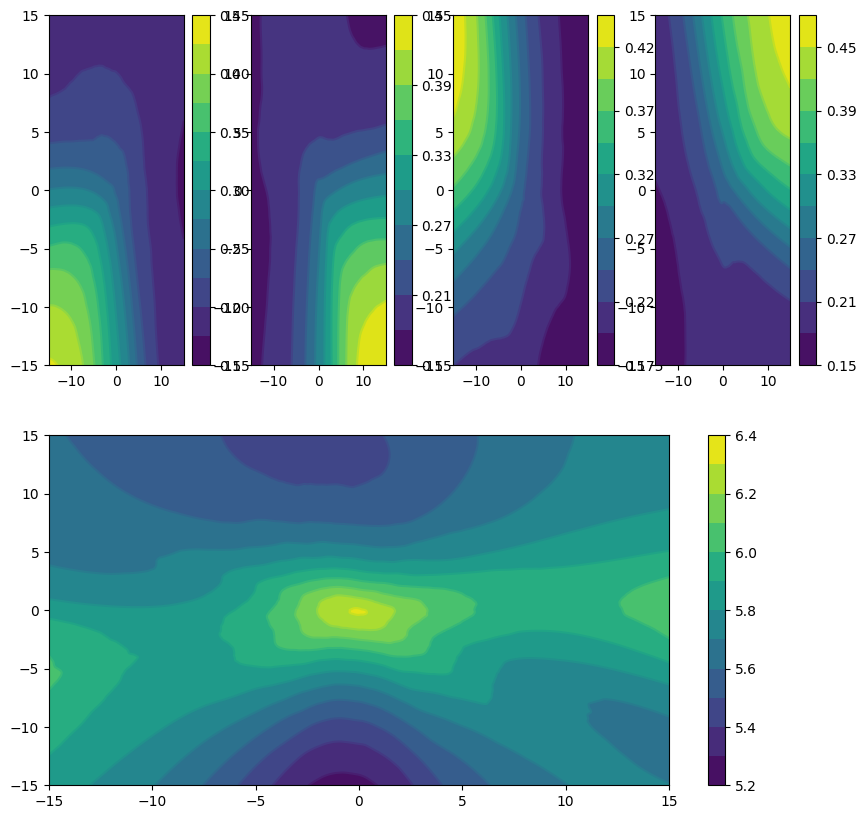

In [8]:
def plot_contour_odd(discriminators, title=None): # Plot discriminator's output as contour plot with optional title
    plt.figure(figsize=(10, 10))
    zs = []
    for i in range(NUM_CLIENTS):
        xx, yy = np.meshgrid(xi, yi)
        x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
        x = torch.from_numpy(x).float().to(device)
        z = discriminators[i](x).detach().cpu().numpy()
        z = z.reshape((ngridy, ngridx))
        # plt.contour(xi, yi, z, levels=10)
        zs.append((z/(1-z+1e-12)))
        print(z.shape)
    zsum = np.sum(zs, axis=0)
    for i in range(NUM_CLIENTS):
        plt.subplot(2, NUM_CLIENTS, i+1)
        z = zs[i]/zsum
        plt.contour(xi, yi, z, levels=10)
        plt.contourf(xi, yi, z, levels=10)
        plt.colorbar()
    plt.subplot(2, 1, 2)
    plt.contour(xi, yi, zsum, levels=10)
    plt.contourf(xi, yi, zsum, levels=10)
    plt.colorbar()
    plt.show()

plot_contour_odd(discriminators, title="Discriminator output")
    

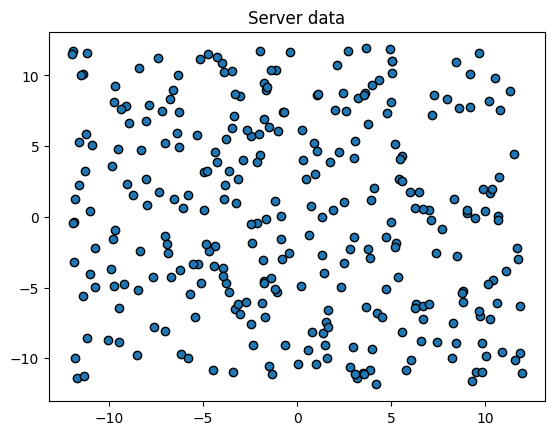

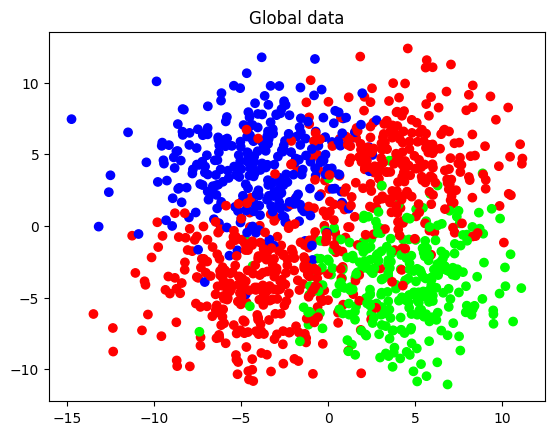

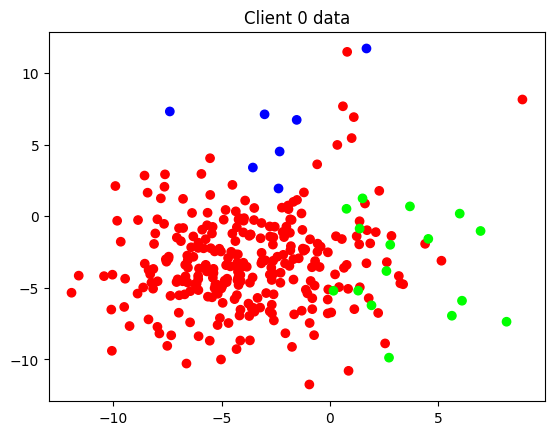

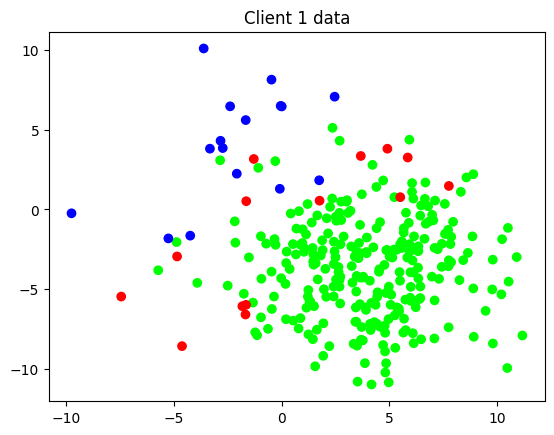

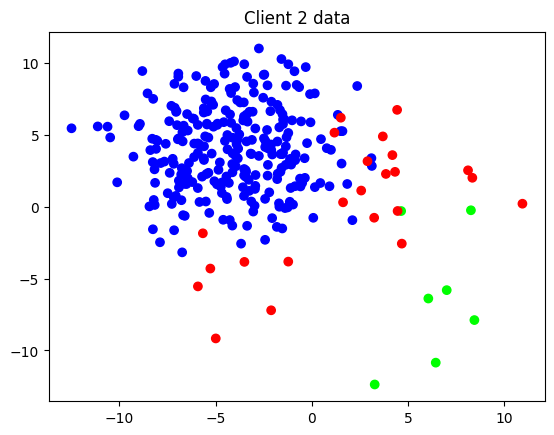

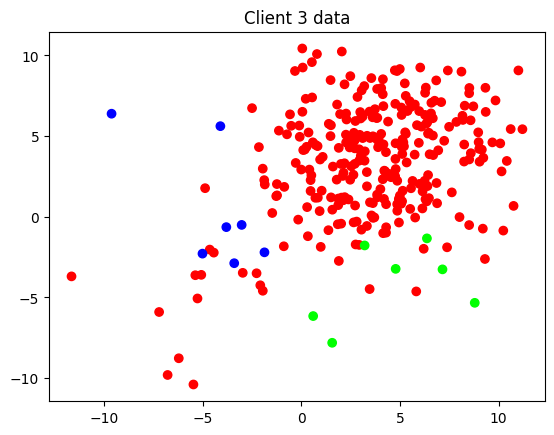

In [9]:
p1 = P
p2 = P 
p3 = P 
p4 = P 
p = [p1, p2, p3, p4]

def share(l, p):
    n = int(len(l) * p)
    idx = np.random.choice(len(l), n, replace=False) # 랜덤한 인덱스 생성
    keep = l[idx] 
    give = np.delete(l, idx, axis=0) 
    np.random.shuffle(give) 
    m = len(give) // NUM_CLIENTS 
    give1 = give[:m] 
    give2 = give[m:2*m] 
    give3 = give[2*m:] 
    return keep, give1, give2 , give3

new_l = [] 
gives = []
for i in range(NUM_CLIENTS): 
    keep, *give = share(client_data[i], p[i])
    new_l.append(keep)
    gives.append(give)
for i in range(NUM_CLIENTS):
    for j in range(NUM_CLIENTS-1): 
        new_l[(i+j+1)%NUM_CLIENTS] = np.concatenate([new_l[(i+j+1)%NUM_CLIENTS], gives[i][j]], axis=0) 


plot_data(server_data, title="Server data") 
plot_data(global_data, title="Global data", labels = global_data[:,2])
for i in range(NUM_CLIENTS): 
    plot_data(new_l[i], title=f"Client {i} data", labels = new_l[i][:,2])

clients_dls = [torch.utils.data.DataLoader(torch.from_numpy(new_l[i]).float(), batch_size=BATCH_SIZE, shuffle=True) for i in range(NUM_CLIENTS)] # Client data loaders

(500, 500)
(500, 500)
(500, 500)
(500, 500)


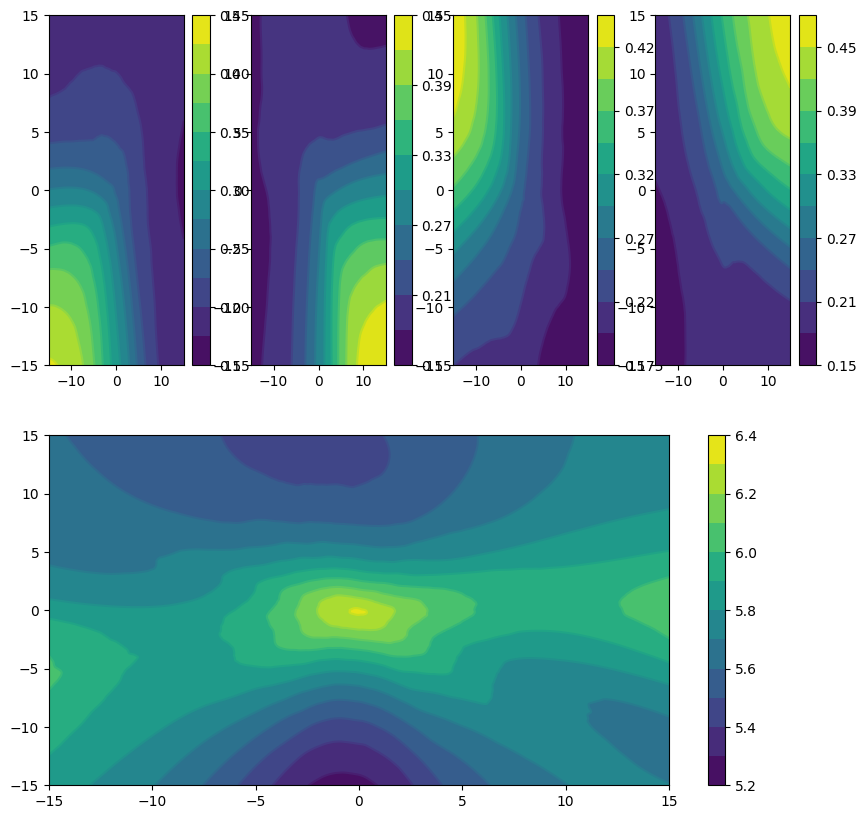

In [10]:
plot_contour_odd(discriminators, title="Discriminator output")

In [11]:
_fix_seed(123)
server_classifier = Classifier().to(device)
discriminators = [cDiscriminator().to(device) for _ in range(NUM_CLIENTS)]
Classifiers = [Classifier().to(device) for _ in range(NUM_CLIENTS)]

cls_optimizer = optim.Adam(server_classifier.parameters(), lr=CLS_LR)
dis_optimizers = [optim.RMSprop(discriminator.parameters(), lr=LR) for discriminator in discriminators]
cls_optimizers = [optim.Adam(Classifier.parameters(), lr=CLS_LR) for Classifier in Classifiers]


for t in range(DISC_EPOCHS):
    dloss_c_tot = 0
    for i in range(NUM_CLIENTS): 
        discriminators[i], dloss_c = c_disc_train(discriminators[i], dis_optimizers[i], clients_dls[i], 1, device)
    dloss_c_tot += dloss_c
    print(f"Client D loss: {dloss_c_tot:.4f}")

Client D loss: 1.3672


In [12]:
# classifiers train
for t in range(C_EPOCHS):
    closs_c_tot = 0
    for i in range(NUM_CLIENTS): 
        Classifiers[i], closs_c = train_cls(Classifiers[i], cls_optimizers[i], clients_dls[i], 1, device)
    closs_c_tot += closs_c
    # gloss_c_tot += gloss_c
    print(f"Client C loss: {closs_c_tot:.4f}")
    



avg_model = Classifier().to(device)
avg_model.load_state_dict(Classifiers[0].state_dict())
for classifier in Classifiers[1:]:
    for param, avg_param in zip(classifier.parameters(), avg_model.parameters()):
        avg_param.data += param.data
for avg_param in avg_model.parameters():
    avg_param.data /= len(Classifiers)

unif_ens_model = Classifier().to(device)
unif_ens_model.load_state_dict(server_classifier.state_dict())
unif_ens_optimizer = optim.Adam(unif_ens_model.parameters(), lr=CLS_LR)
unif_ens_model, unif_ens_loss = ensemble_train(unif_ens_model, unif_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'unif')

disc_ens_model = Classifier().to(device)
disc_ens_model.load_state_dict(server_classifier.state_dict())
disc_ens_optimizer = optim.Adam(disc_ens_model.parameters(), lr=CLS_LR)
disc_ens_model, disc_ens_loss = ensemble_train(disc_ens_model, disc_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'disc')

logit_ens_model = Classifier().to(device)
logit_ens_model.load_state_dict(server_classifier.state_dict())
logit_ens_optimizer = optim.Adam(logit_ens_model.parameters(), lr=CLS_LR)
logit_ens_model, logit_ens_loss = ensemble_train(logit_ens_model, logit_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'logit_var')

entropy_ens_model = Classifier().to(device)
entropy_ens_model.load_state_dict(server_classifier.state_dict())
entropy_ens_optimizer = optim.Adam(entropy_ens_model.parameters(), lr=CLS_LR)
entropy_ens_model, entropy_ens_loss = ensemble_train(entropy_ens_model, entropy_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'entropy')

dafkd_ens_model = Classifier().to(device)
dafkd_ens_model.load_state_dict(server_classifier.state_dict())
dafkd_ens_optimizer = optim.Adam(dafkd_ens_model.parameters(), lr=CLS_LR)
dafkd_ens_model, dafkd_ens_loss = ensemble_train(dafkd_ens_model, dafkd_ens_optimizer, Classifiers, server_dl, device, S_EPOCHS, 'dafkd')


Client C loss: 0.6359
Client C loss: 0.2220
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 64, 3])
torch.Size([4, 44, 3])


(500, 500)


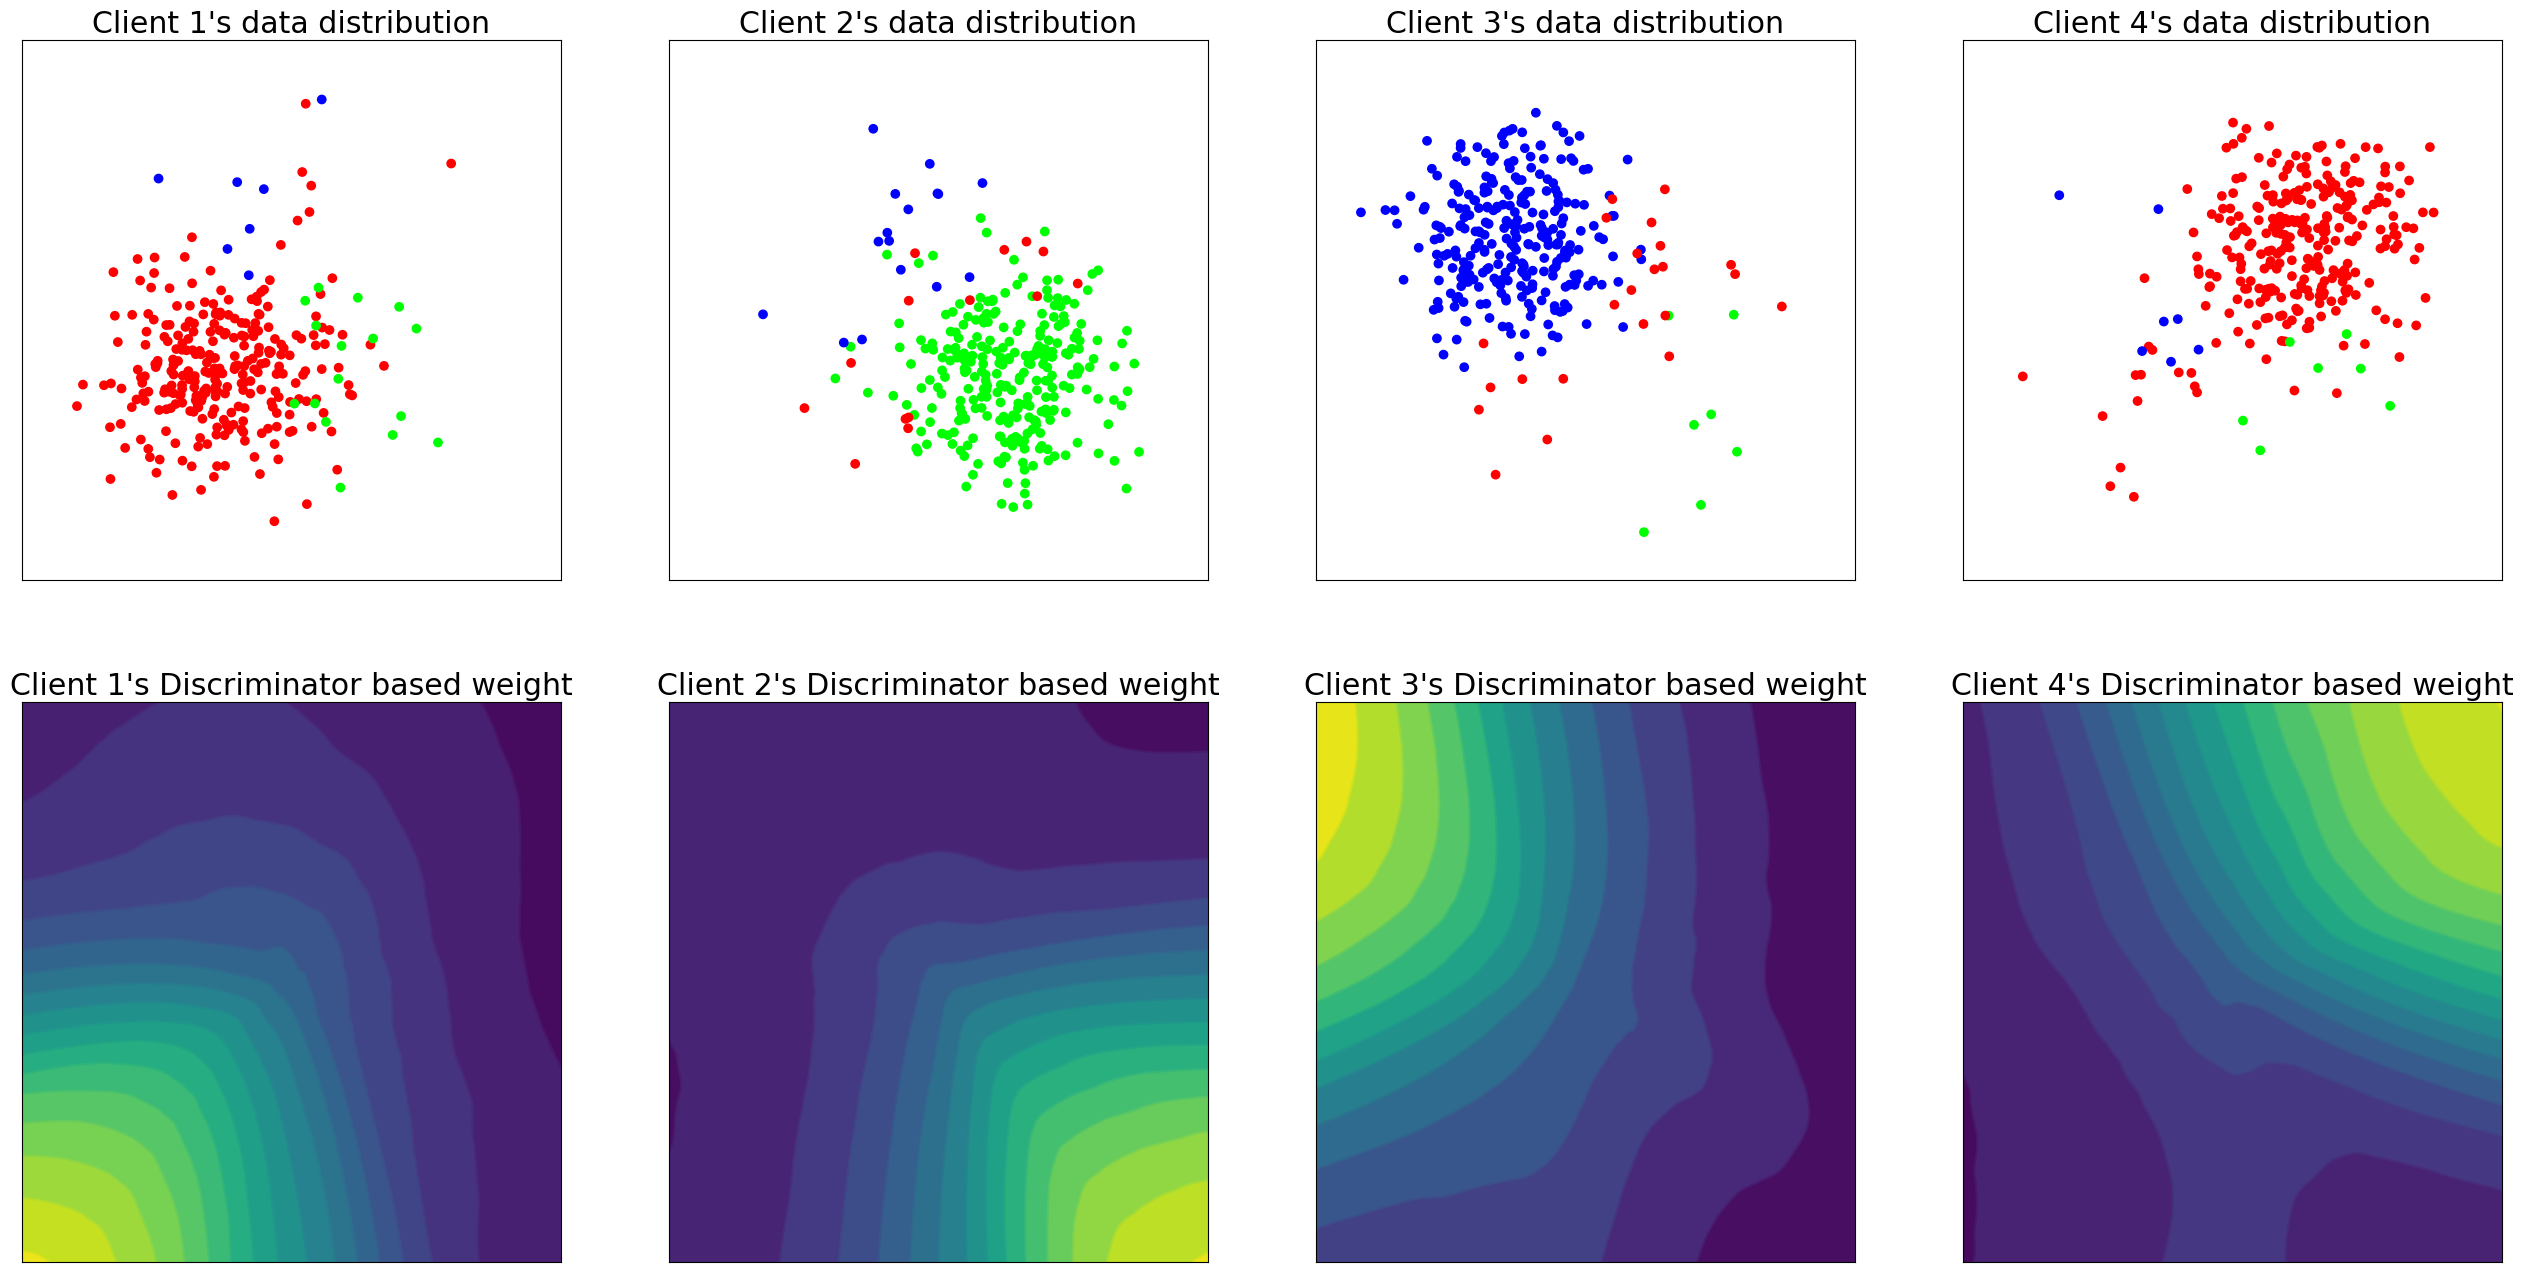

In [14]:
plt.close()
plt.figure(figsize=(32, 16))
plt.rcParams.update({'font.size': 18})

for i in range(NUM_CLIENTS):
    plt.subplot(2, NUM_CLIENTS, i+1)
    plt.xticks([])
    plt.yticks([])
    plot_white_box(new_l[i], title=f"Client {i+1}'s data distribution", show=False, labels=new_l[i][:,2])

zs = []
xx, yy = np.meshgrid(xi, yi)
x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
x = torch.from_numpy(x).float().to(device)
for i in range(NUM_CLIENTS):
    z = discriminators[i](x).detach().cpu().numpy()
    z = z.reshape((ngridy, ngridx))
    # plt.contour(xi, yi, z, levels=10)
    zs.append((z/(1-z+1e-12)))
print(z.shape)
zsum = np.sum(zs, axis=0)
for i in range(NUM_CLIENTS):
    plt.subplot(2, NUM_CLIENTS, NUM_CLIENTS +i+1)
    plt.xticks([])
    plt.yticks([])
    z = zs[i]/zsum
    plt.contour(xi, yi, z, levels=15)
    plt.contourf(xi, yi, z, levels=15)
    plt.title(f"Client {i+1}'s Discriminator based weight")
    # plt.colorbar()


plt.savefig('data/Client_weights.png')
plt.savefig('data/Client_weights.pdf')

(500, 500)


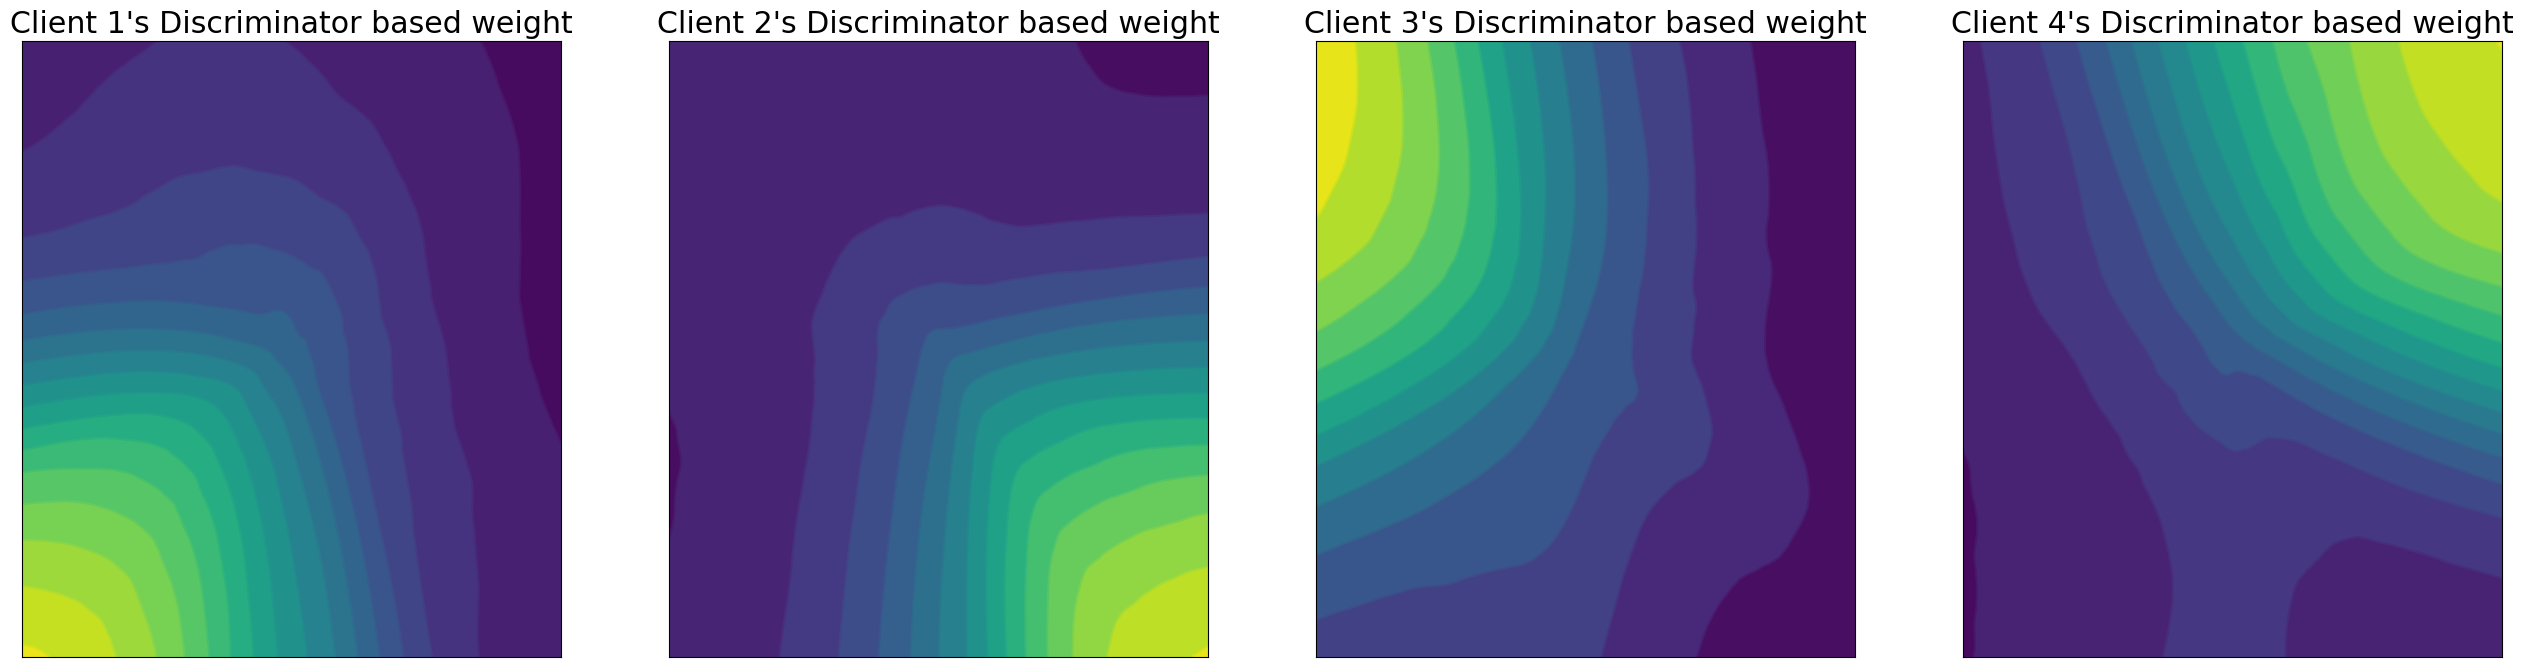

In [15]:
plt.figure(figsize=(32, 8))
plt.rcParams.update({'font.size': 18})

zs = []
xx, yy = np.meshgrid(xi, yi)
x = np.concatenate((xx.reshape(-1,1), yy.reshape(-1,1)), axis=1)
x = torch.from_numpy(x).float().to(device)
for i in range(NUM_CLIENTS):
    z = discriminators[i](x).detach().cpu().numpy()
    z = z.reshape((ngridy, ngridx))
    # plt.contour(xi, yi, z, levels=10)
    zs.append((z/(1-z+1e-12)))
print(z.shape)
zsum = np.sum(zs, axis=0)
for i in range(NUM_CLIENTS):
    plt.subplot(1, NUM_CLIENTS, i+1)
    plt.xticks([])
    plt.yticks([])
    z = zs[i]/zsum
    plt.contour(xi, yi, z, levels=15)
    plt.contourf(xi, yi, z, levels=15)
    plt.title(f"Client {i+1}'s Discriminator based weight")
    # plt.colorbar()


plt.savefig('data/Client_weights.png')
plt.savefig('data/Client_weights.pdf')

torch.Size([4, 250000, 3])
torch.Size([4, 250000, 3])


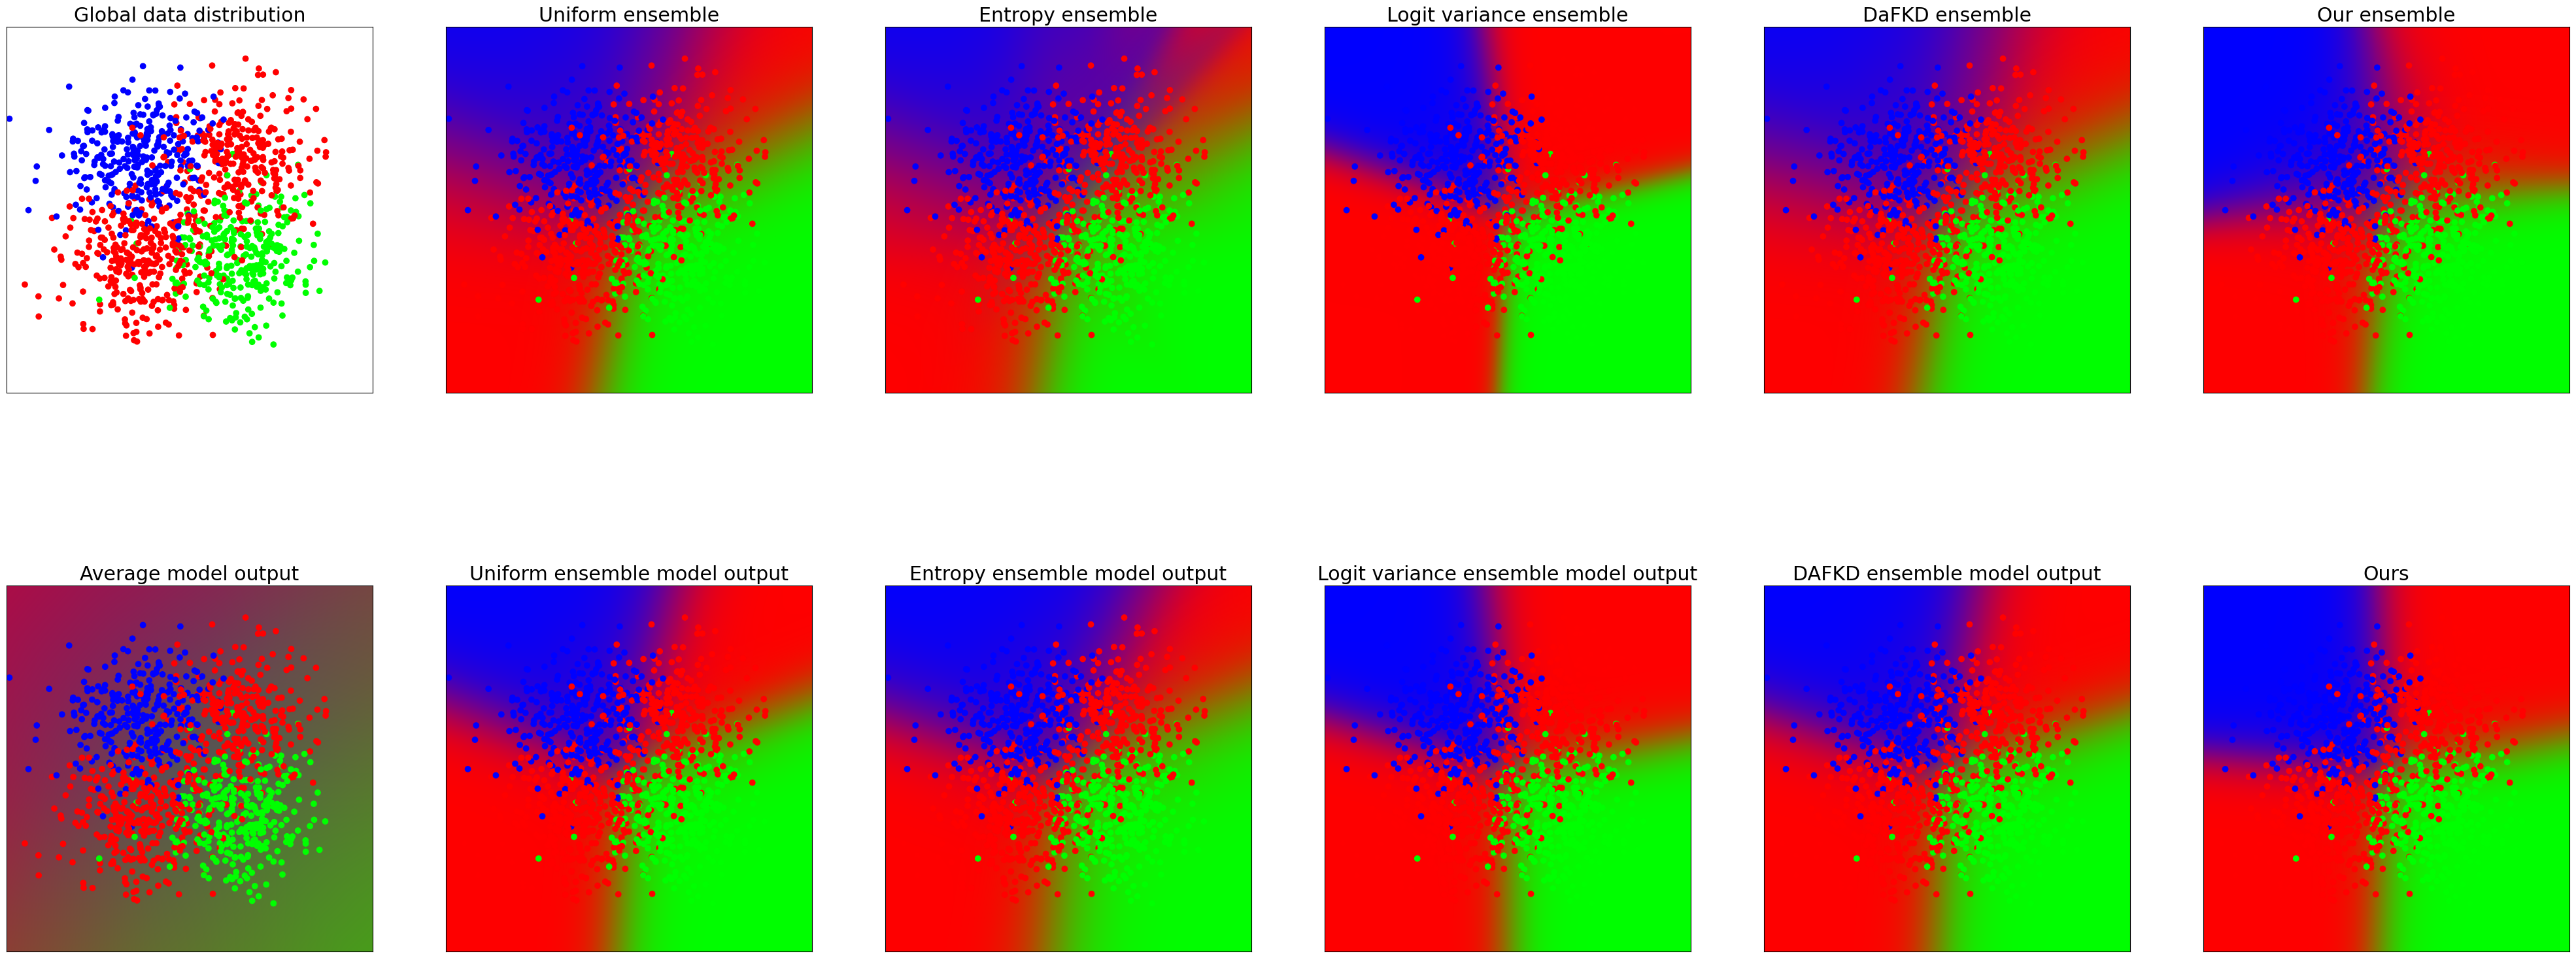

In [16]:

# plot_unif_ensemble(Classifiers, title="Classifier output")
# plot_disc_ensemble(Classifiers, discriminators, title="Discriminator output")
plt.figure(figsize=(40,16))
plt.subplot(2, 6, 1)
plt.xticks([])
plt.yticks([])
plot_white_box(title="Global data distribution", show=False, labels=global_data[:,2])
plt.subplot(2, 6, 2)
plt.xticks([])
plt.yticks([])
plot_ensemble(Classifiers, title="Uniform ensemble", method='unif', show=False)
plt.subplot(2, 6, 3)
plot_ensemble(Classifiers, title="Entropy ensemble", method='entropy', show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 4)
plot_ensemble(Classifiers, title="Logit variance ensemble", method='logit_var', show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 5)
plt.xticks([])
plt.yticks([])
plot_ensemble(Classifiers, discriminators, title="DaFKD ensemble", method='dafkd', show=False)
plt.subplot(2, 6, 6)
plot_ensemble(Classifiers, discriminators, title="Our ensemble", method='disc', show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 7)
plot_server_model(avg_model, title="Average model output", show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 8)
plot_server_model(unif_ens_model, title="Uniform ensemble model output", show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 9)
plot_server_model(entropy_ens_model, title="Entropy ensemble model output", show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 10)
plot_server_model(logit_ens_model, title="Logit variance ensemble model output", show=False)
plt.xticks([])
plt.yticks([])
plt.subplot(2, 6, 11)
plt.xticks([])
plt.yticks([])
plot_server_model(dafkd_ens_model, title="DAFKD ensemble model output", show=False)
plt.subplot(2, 6, 12)
plot_server_model(disc_ens_model, title="Ours", show=False)
plt.xticks([])
plt.yticks([])

plt.subplots_adjust(left = 0.01, right=0.99, bottom=0.01, top=0.99)
plt.savefig('data/fig1_.pdf')
plt.savefig('data/fig1_.png')

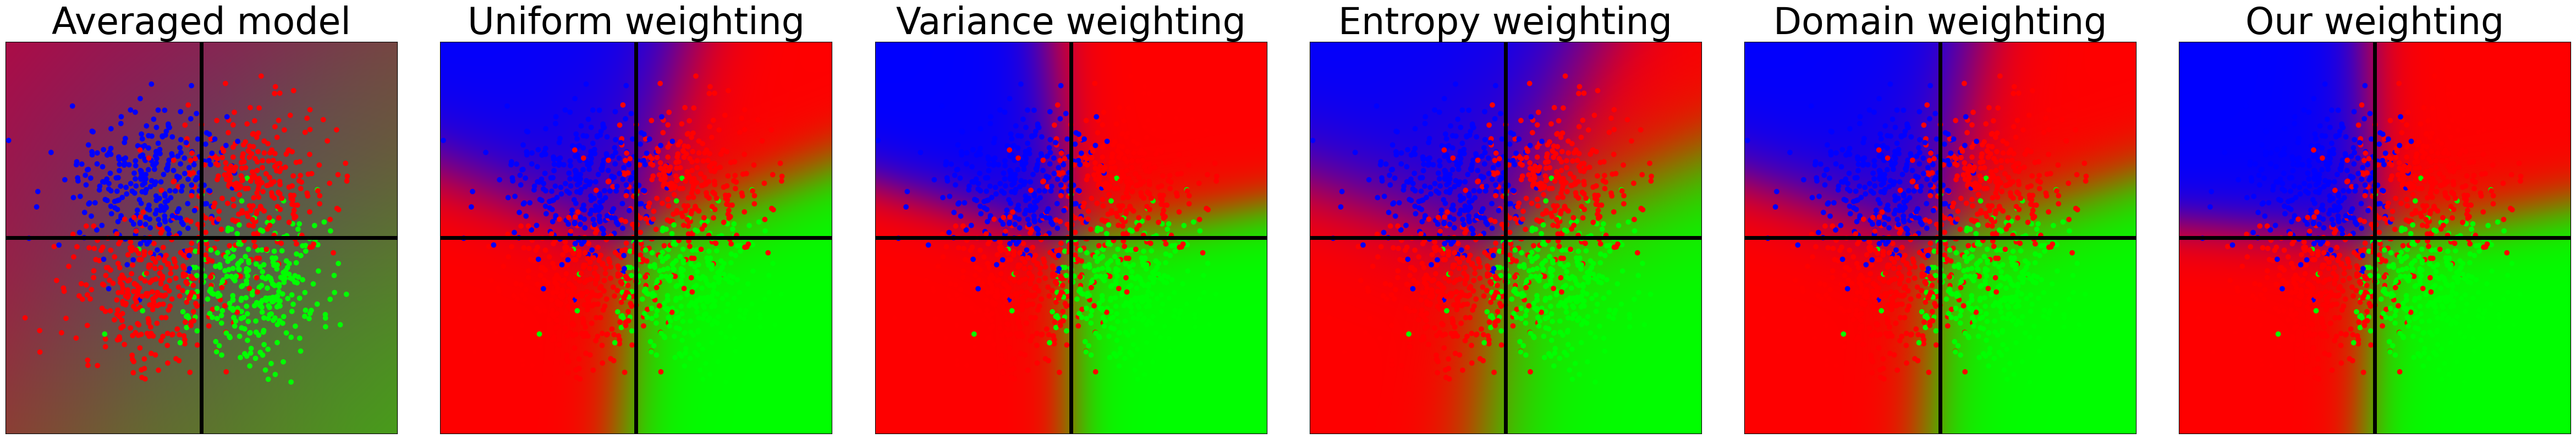

In [17]:
linewidth = 5

plt.figure(figsize=(48,8))
plt.rcParams.update({'font.size': 40})
plt.subplot(1, 6, 1)
plot_server_model(avg_model, title="Averaged model", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 2)
plot_server_model(unif_ens_model, title="Uniform weighting", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 3)
plot_server_model(logit_ens_model, title="Variance weighting", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 4)
plot_server_model(entropy_ens_model, title="Entropy weighting", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 5)
plot_server_model(dafkd_ens_model, title="Domain weighting", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 6)
plot_server_model(disc_ens_model, title="Our weighting", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])

plt.subplots_adjust(left = 0.01, right=0.99, bottom=0.01, top=0.9, hspace=0.05, wspace=0.05)
plt.savefig('data/fig1_.pdf')
plt.savefig('data/fig1_.png')

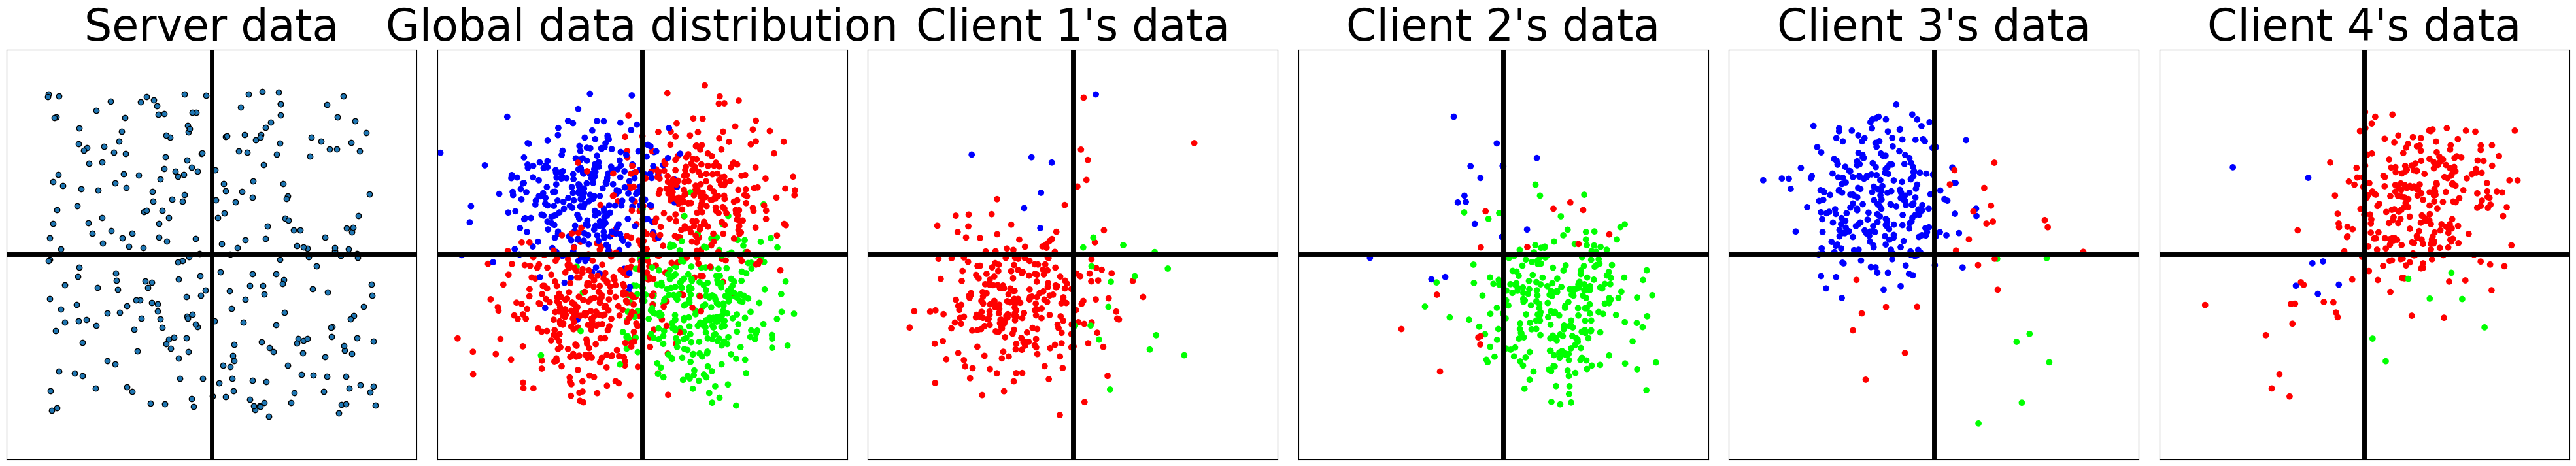

In [18]:
linewidth = 5

plt.figure(figsize=(40,8))
plt.rcParams.update({'font.size': 40})
plt.subplot(1, 6, 1)
plot_white_box(title = "Server data", show=False, data = server_data)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 2)
plot_white_box(title="Global data distribution", show=False, labels=global_data[:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 3)
plot_white_box(data=new_l[0], title="Client 1's data", show=False, labels=new_l[0][:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 4)
plot_white_box(data=new_l[1], title="Client 2's data", show=False, labels=new_l[1][:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 5)
plot_white_box(data=new_l[2], title="Client 3's data", show=False, labels=new_l[2][:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])
plt.subplot(1, 6, 6)
plot_white_box(data=new_l[3], title="Client 4's data", show=False, labels=new_l[3][:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.xticks([])
plt.yticks([])

plt.subplots_adjust(left = 0.01, right=0.99, bottom=0.01, top=0.9, hspace=0.05, wspace=0.05)
plt.savefig('data/fig1_a.pdf')
plt.savefig('data/fig1_a.png')

(250000, 3)
torch.Size([4, 250000, 3])
(250000, 3)


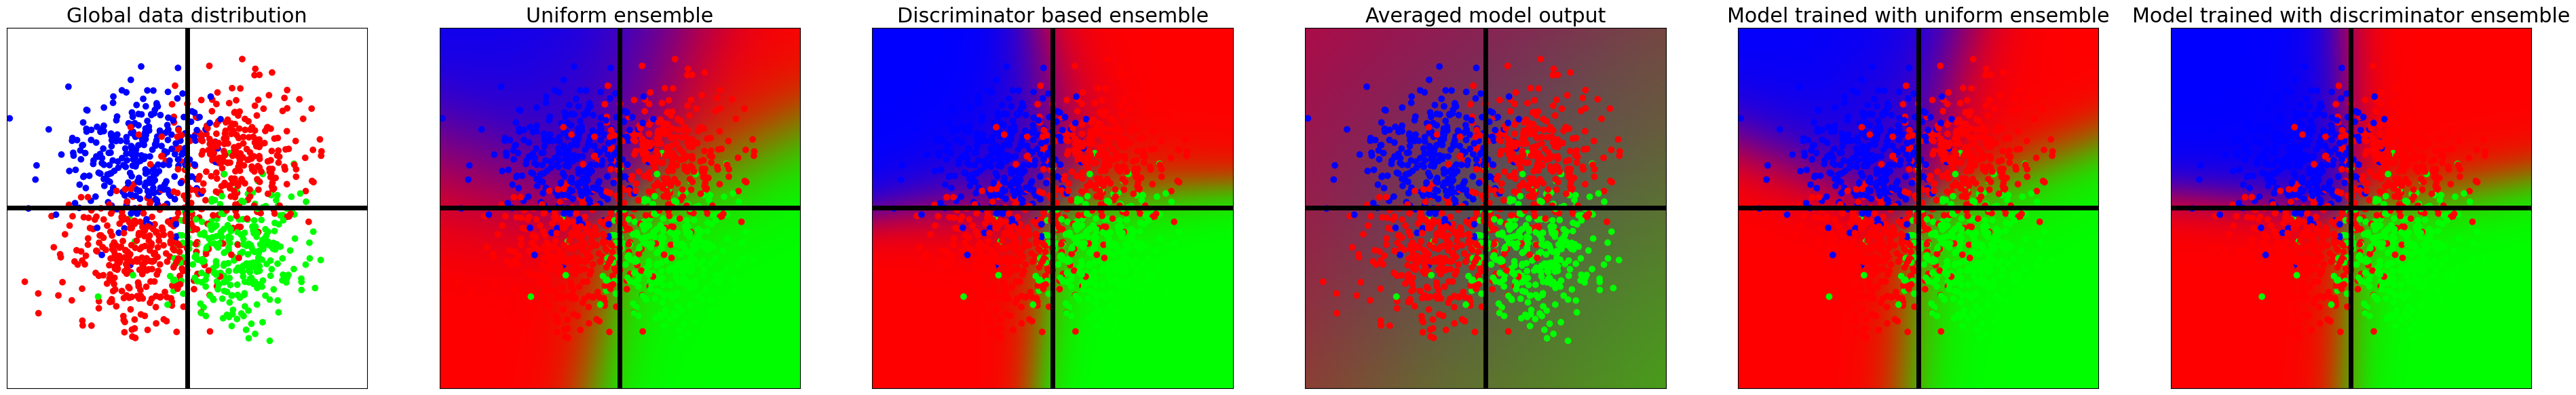

In [19]:
plt.figure(figsize=(48, 8))
plt.rcParams.update({'font.size': 18})

linewidth = 5

plt.subplot(1, 6, 1)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)   
plt.xticks([])
plt.yticks([])
plot_white_box(title="Global data distribution", show=False, labels=global_data[:,2])
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.subplot(1, 6, 2)
plt.xticks([])
plt.yticks([])
plot_unif_ensemble(Classifiers, title="Uniform ensemble", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.subplot(1, 6, 3)
plt.xticks([])
plt.yticks([])
plot_disc_ensemble(Classifiers, discriminators, title="Discriminator based ensemble", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.subplot(1, 6, 4)
plt.xticks([])
plt.yticks([])
plot_server_model(model = avg_model, title="Averaged model output", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
# plt.show()
plt.subplot(1, 6, 5)
plt.xticks([])
plt.yticks([])
plot_server_model(model = unif_ens_model, title="Model trained with uniform ensemble", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
plt.subplot(1, 6, 6)
plt.xticks([])
plt.yticks([])
plot_server_model(model = disc_ens_model, title="Model trained with discriminator ensemble", show=False)
plt.hlines(0, xmin, xmax, color='black', linestyle='solid', linewidth=linewidth)
plt.vlines(0, ymin, ymax, color='black', linestyle='solid', linewidth=linewidth)
# plt.show()
plt.savefig('data/fig1.pdf')
plt.savefig('data/fig1.png')